## History Dataset:

In this notebook, I explore the data related to user job history available on the platform. It includes data loading, preprocessing, and analysis.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading:

In [2]:
# Read data
history = pd.read_csv('../data/raw/users_history.csv')

In [3]:
# Display the first 5 rows
history.head()

,UserID,Sequence,JobTitle,JobCategoryID
0,23,1,Manager,0.0
1,23,2,Assisting customers,30.0
2,698,1,Advocate Bromenn,88.0
3,698,2,"Customer Service, Patient contact, drawing blood",135.0
4,698,3,"Customer Service, Suggestive selling",1.0


In [4]:
# Description of the dataset
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6806 entries, 0 to 6805
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   UserID         6806 non-null   int64  
 1   Sequence       6806 non-null   int64  
 2   JobTitle       6806 non-null   object 
 3   JobCategoryID  6806 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 212.8+ KB


Based on the observations above, I have only identified that JobCategoryID requires datatype modification.

## 2. Data Processing:

In [5]:
# Check duplicated values
duplicate_rows = history.duplicated().sum()
print(f"Duplicated rows: {duplicate_rows}")

Duplicated rows: 0


In [6]:
# Check the missing values
history.isnull().sum()

UserID           0
Sequence         0
JobTitle         0
JobCategoryID    0
dtype: int64

In [7]:
# Convert JobCategory to integer values
history['JobCategoryID'] = pd.to_numeric(history['JobCategoryID'], errors='coerce')
history['JobCategoryID'] = history['JobCategoryID'].round()
history['JobCategoryID'] = history['JobCategoryID'].astype('Int64')

## 3. Data Cleaning:

In [8]:
# A function to clean the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [9]:
# Clean jobtitle
history['JobTitle'] = history['JobTitle'].apply(clean_text)

In this section, I have cleaned the job title to improve text quality and prepare the data for further analysis.

## 4. Data Analysis:

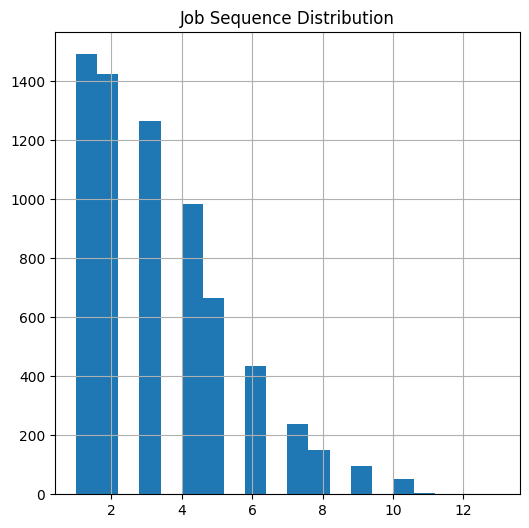

In [10]:
# Job sequence distribution
plt.figure(figsize=(6, 6))
history['Sequence'].hist(bins=20)
plt.title("Job Sequence Distribution")
plt.show()

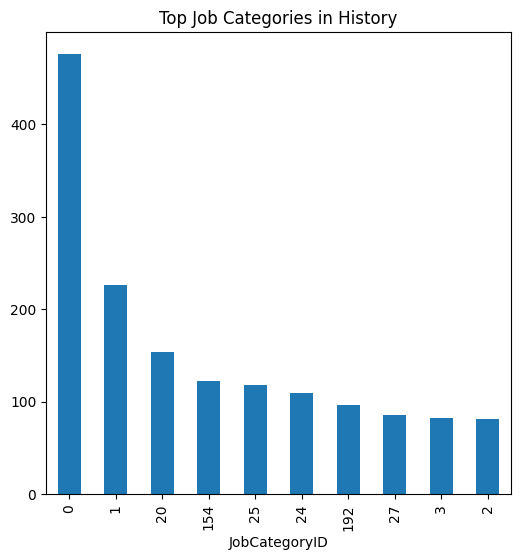

In [11]:
# Top job categories in history
plt.figure(figsize=(6, 6))
history['JobCategoryID'].value_counts().head(10).plot(kind='bar')
plt.title("Top Job Categories in History")
plt.show()

This section analyzes users job history records by examining the distribution of job sequences and the most frequent job categories appearing in historical data. These visualizations provide insights into users career progression and past employment trends.

## 5. Save Cleaned Dataset:

In [12]:
history.to_csv("../data/clean/history_cleaned.csv", index=False)